In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/home/cnovak/src/python/pymc/.venv/lib64/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
# Data
N = 100  # Number of experiments
k = 60   # Number of successes

In [4]:
alpha_val = 2
beta_val = 10

In [5]:
import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.28.2


In [6]:
# Define the model
with pm.Model() as bernoulli_model:
    # Beta prior for the probability of success
    # Parameters: alpha (prior successes), beta (prior failures)
    p = pm.Beta("p", alpha=alpha_val, beta=beta_val)

    # Bernoulli likelihood
    # We use a Binomial likelihood for efficiency (equivalent to N Bernoulli trials)
    obs = pm.Binomial("obs", n=N, p=p, observed=k)

    # Sample from the posterior
    trace = pm.sample(10000, tune=1000, chains=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 32 seconds.


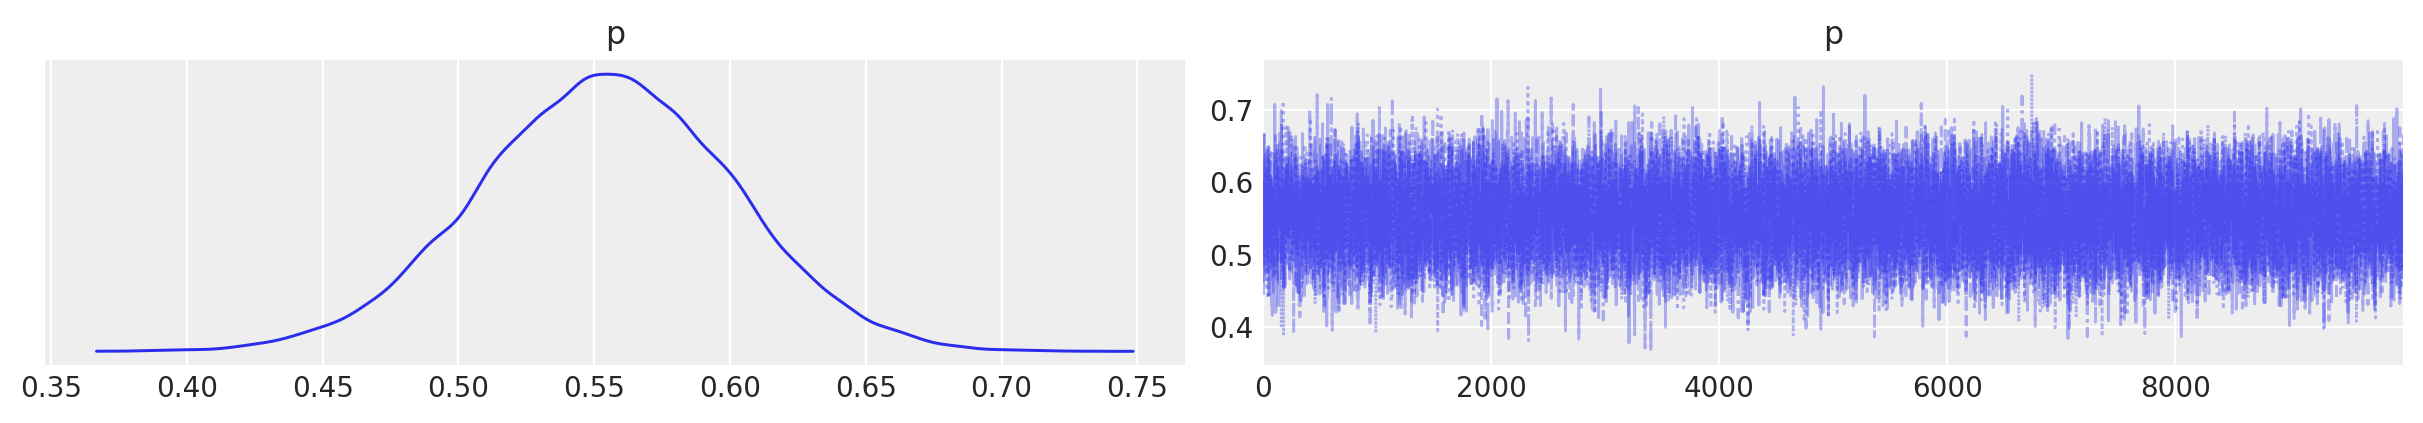

In [7]:
az.plot_trace(trace, combined=True);

In [8]:
az.summary(trace, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.55,0.05,0.47,0.64,0.0,0.0,17079.28,27758.9,1.0


In [9]:
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# Generate values for the x-axis (probability of success)
x = np.linspace(0, 1, 1000)

# Calculate the Beta PDF (Probability Density Function)
pdf = beta.pdf(x, alpha_val, beta_val)
# Calculate the Binomial likelihood
likelihood = binom.pmf(k, N, x)

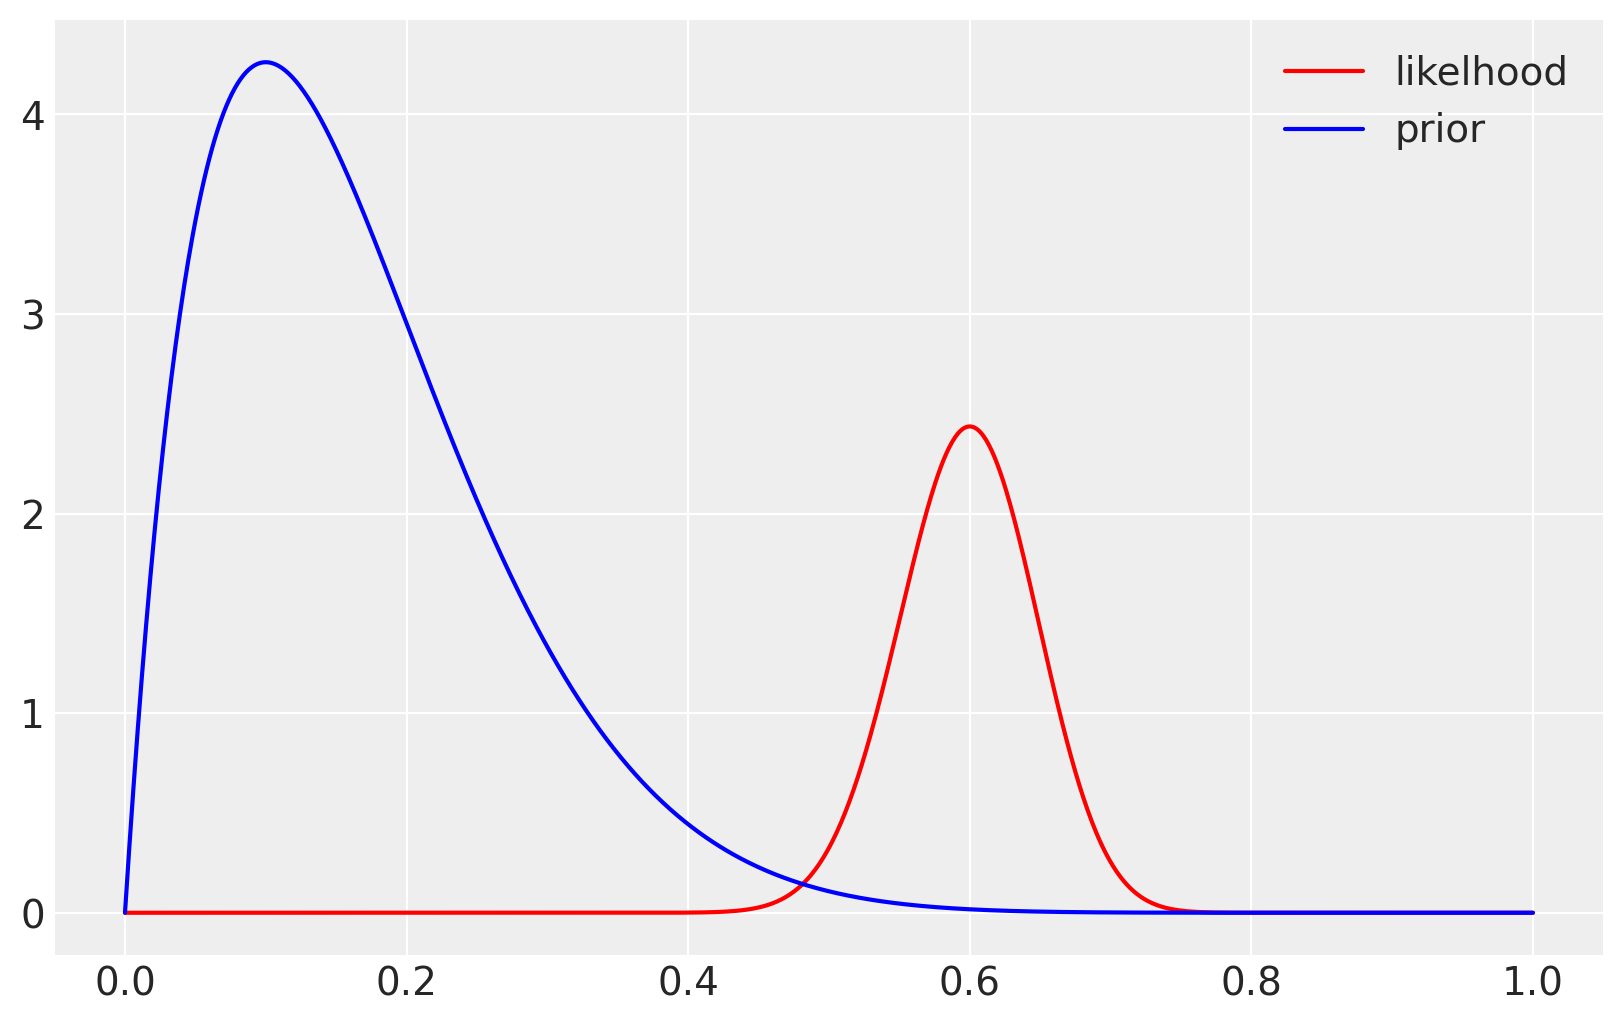

In [10]:
# Plot the likelihood
plt.figure(figsize=(8, 5))
plt.plot(x, 30*likelihood, color='red', label='likelhood')

# Plot the Beta prior
plt.plot(x, pdf, color='blue', label='prior')
plt.grid(True)
plt.legend()